# Muscle Definition Prediction using Random Forest

This notebook predicts muscle definition metrics using Random Forest Regressor based on workout data and personal characteristics.

## Targets to Predict:
- Body fat percentage change (negative or positive %)
- Muscle mass index
- High muscle mass potential (true/false)
- Definition score (1-10 float)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Create sample dataset (replace this with your actual data loading)
def create_sample_dataset(n_samples=1000):
    np.random.seed(42)
    
    exercises = ['Bench Press', 'Squat', 'Deadlift', 'Pull-ups', 'Bicep Curls', 'Tricep Extensions', 'Shoulder Press']
    muscle_groups = ['Chest', 'Legs', 'Back', 'Arms', 'Shoulders', 'Core']
    exercise_types = ['compound', 'isolation']
    genders = ['M', 'F']
    experience_levels = ['Beginner', 'Intermediate', 'Advanced']
    
    data = {
        'exerciseName': np.random.choice(exercises, n_samples),
        'targetMuscleGroup': np.random.choice(muscle_groups, n_samples),
        'type': np.random.choice(exercise_types, n_samples),
        'age': np.random.randint(18, 65, n_samples),
        'gender': np.random.choice(genders, n_samples),
        'sets': np.random.randint(3, 6, n_samples),
        'reps': np.random.randint(8, 15, n_samples),
        'geneticAdvantage': np.random.randint(1, 11, n_samples),
        'weightLifted': np.random.randint(0, 200, n_samples),
        'frequency': np.random.randint(3, 8, n_samples),
        'protein_consumed': np.random.randint(80, 200, n_samples),
        'calories_consumed': np.random.randint(1800, 3000, n_samples),
        'caloric_deficit': np.random.randint(-500, 500, n_samples),
        'sleep': np.random.uniform(5, 10, n_samples),
        'experience': np.random.choice(experience_levels, n_samples),
        'current_weight': np.random.uniform(50, 120, n_samples),
        'height': np.random.uniform(150, 200, n_samples),
        'BFP_after_3_months': np.random.uniform(8, 25, n_samples),
        'BFP_after_6_months': np.random.uniform(8, 25, n_samples),
        'BFP_after_9_months': np.random.uniform(8, 25, n_samples),
        'BFP_after_12_months': np.random.uniform(8, 25, n_samples),
        'actual_definition_scores': np.random.uniform(1, 10, n_samples)
    }
    
    return pd.DataFrame(data)

# Create sample dataset
df = create_sample_dataset()
print(f"Dataset created with {len(df)} samples")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset created with 1000 samples
Dataset shape: (1000, 22)


,exerciseName,targetMuscleGroup,type,age,gender,sets,reps,geneticAdvantage,weightLifted,frequency,...,caloric_deficit,sleep,experience,current_weight,height,BFP_after_3_months,BFP_after_6_months,BFP_after_9_months,BFP_after_12_months,actual_definition_scores
0,Shoulder Press,Legs,compound,53,female,5,8,8,79,5,...,16,7.938977,intermediate,103.895341,187.208550,10.332652,8.846605,21.318965,14.831490,4.833757
1,Pull-ups,Back,isolation,55,male,5,12,7,70,4,...,261,9.236484,beginner,110.023968,194.852369,18.014978,11.070662,24.570528,23.960616,2.711603
2,Bicep Curls,Chest,compound,56,female,4,13,1,77,7,...,174,7.206372,beginner,50.012964,196.307917,23.267999,19.007632,17.936866,18.324646,2.993408
3,Shoulder Press,Shoulders,compound,54,male,5,10,4,42,4,...,2,5.089789,intermediate,75.370199,168.942481,21.482225,10.318216,15.582635,10.692617,4.987360
4,Deadlift,Shoulders,isolation,52,male,4,12,7,153,7,...,213,5.372552,intermediate,101.632217,158.678034,17.290773,18.019476,11.787160,16.536524,7.914004


In [3]:
# Data preprocessing function
def preprocess_data(df):
    df = df.copy()
    
    # Volume and intensity calculations
    df['volume'] = df['sets'] * df['reps']
    df['intensity'] = np.where(df['reps'] > 0, df['weightLifted'] / df['reps'], 0)
    
    # Ensure frequency is capped at 7
    df['frequency'] = np.clip(df['frequency'], 0, 7)
    
    # BMI calculation
    df['bmi'] = df['current_weight'] / ((df['height'] / 100) ** 2)
    
    # Encode categorical variables
    le_exercise = LabelEncoder()
    le_muscle = LabelEncoder()
    le_type = LabelEncoder()
    le_gender = LabelEncoder()
    le_experience = LabelEncoder()
    
    df['exerciseName_encoded'] = le_exercise.fit_transform(df['exerciseName'])
    df['targetMuscleGroup_encoded'] = le_muscle.fit_transform(df['targetMuscleGroup'])
    df['type_encoded'] = le_type.fit_transform(df['type'])
    df['gender_encoded'] = le_gender.fit_transform(df['gender'])
    df['experience_encoded'] = le_experience.fit_transform(df['experience'])
    
    # Store encoders for later use
    encoders = {
        'exercise': le_exercise,
        'muscle': le_muscle,
        'type': le_type,
        'gender': le_gender,
        'experience': le_experience
    }
    
    return df, encoders

# Preprocess the data
df_processed, encoders = preprocess_data(df)
print("Data preprocessing completed!")
print(f"New features added: volume, intensity, bmi")
print(f"Categorical variables encoded")
df_processed[['volume', 'intensity', 'bmi']].head()

Data preprocessing completed!
New features added: volume, intensity, bmi
Categorical variables encoded


,volume,intensity,bmi
0,40,9.875000,29.644540
1,60,5.833333,28.978501
2,52,5.923077,12.977976
3,50,4.200000,26.407174
4,48,12.750000,40.364333


In [4]:
# Calculate baseline metrics using mathematical equations
def calculate_baseline_metrics(df):
    df = df.copy()
    
    # BFP change baseline (simplified metabolic model)
    df['baseline_bfp_change'] = (
        -0.1 * df['caloric_deficit'] * df['frequency'] / df['current_weight'] 
        + 0.05 * (df['geneticAdvantage'] - 5) / 10
        - 0.02 * df['age']
        + 0.1 * (df['sleep'] - 7) / 2
    )
    
    # Muscle Mass Index baseline
    df['baseline_mmi'] = (
        df['volume'] * df['intensity'] * df['frequency'] * df['protein_consumed'] 
        / (df['current_weight'] * 1000) 
        * (df['geneticAdvantage'] / 10)
        * (1 + 0.1 * (df['experience_encoded']))
    )
    
    # High muscle mass potential (genetic + training factors)
    df['baseline_high_potential'] = (
        (df['geneticAdvantage'] >= 7) & 
        (df['volume'] >= df['volume'].quantile(0.7)) &
        (df['protein_consumed'] >= df['current_weight'] * 1.6)
    ).astype(float)
    
    # Definition score baseline
    df['baseline_definition'] = (
        (20 - df['BFP_after_12_months']) * 0.3 +  # Lower BFP = better definition
        df['baseline_mmi'] * 0.4 +  # More muscle mass = better definition
        (df['volume'] * df['frequency'] / 100) * 0.3
    )
    df['baseline_definition'] = np.clip(df['baseline_definition'], 1, 10)
    
    return df

# Calculate baseline metrics
df_processed = calculate_baseline_metrics(df_processed)
print("Baseline metrics calculated!")
print("\nBaseline metrics summary:")
baseline_cols = ['baseline_bfp_change', 'baseline_mmi', 'baseline_high_potential', 'baseline_definition']
df_processed[baseline_cols].describe()

Baseline metrics calculated!

Baseline metrics summary:


,baseline_bfp_change,baseline_mmi,baseline_high_potential,baseline_definition
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.896900,2.016028,0.062000,2.700251
std,1.922581,2.159188,0.241276,1.553463
min,-6.778367,0.000000,0.000000,1.000000
25%,-2.264318,0.549963,0.000000,1.224946
50%,-0.931949,1.298975,0.000000,2.454100
75%,0.459397,2.766802,0.000000,3.711210
max,5.383568,17.035355,1.000000,9.331257


In [5]:
# Build Random Forest models
def build_rf_models(df):
    # Feature columns (exclude targets and intermediate calculations)
    feature_cols = [
        'exerciseName_encoded', 'targetMuscleGroup_encoded', 'type_encoded',
        'age', 'gender_encoded', 'volume', 'intensity', 'geneticAdvantage',
        'frequency', 'protein_consumed', 'calories_consumed', 'caloric_deficit',
        'sleep', 'experience_encoded', 'current_weight', 'height', 'bmi'
    ]
    
    X = df[feature_cols]
    
    models = {}
    scores = {}
    
    # BFP Change Model
    y_bfp = df['baseline_bfp_change']  # Use baseline + some noise
    X_train, X_test, y_train, y_test = train_test_split(X, y_bfp, test_size=0.2, random_state=42)
    
    rf_bfp = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
    rf_bfp.fit(X_train, y_train)
    models['bfp_change'] = rf_bfp
    
    # Calculate score
    y_pred_bfp = rf_bfp.predict(X_test)
    scores['bfp_change'] = r2_score(y_test, y_pred_bfp)
    
    # Muscle Mass Index Model
    y_mmi = df['baseline_mmi']
    X_train, X_test, y_train, y_test = train_test_split(X, y_mmi, test_size=0.2, random_state=42)
    
    rf_mmi = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
    rf_mmi.fit(X_train, y_train)
    models['muscle_mass_index'] = rf_mmi
    
    y_pred_mmi = rf_mmi.predict(X_test)
    scores['muscle_mass_index'] = r2_score(y_test, y_pred_mmi)
    
    # High Potential Model (using classifier)
    y_potential = df['baseline_high_potential']
    X_train, X_test, y_train, y_test = train_test_split(X, y_potential, test_size=0.2, random_state=42)
    
    rf_potential = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    rf_potential.fit(X_train, y_train)
    models['high_potential'] = rf_potential
    
    y_pred_potential = rf_potential.predict(X_test)
    scores['high_potential'] = accuracy_score(y_test, y_pred_potential)
    
    # Definition Score Model
    y_definition = df['actual_definition_scores']  # Use actual scores
    X_train, X_test, y_train, y_test = train_test_split(X, y_definition, test_size=0.2, random_state=42)
    
    rf_definition = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
    rf_definition.fit(X_train, y_train)
    models['definition_score'] = rf_definition
    
    y_pred_definition = rf_definition.predict(X_test)
    scores['definition_score'] = r2_score(y_test, y_pred_definition)
    
    return models, feature_cols, scores

# Build models
models, feature_cols, model_scores = build_rf_models(df_processed)
print("Random Forest models trained!")
print("\nModel Performance Scores:")
for model_name, score in model_scores.items():
    if model_name == 'high_potential':
        print(f"{model_name}: {score:.4f} (Accuracy)")
    else:
        print(f"{model_name}: {score:.4f} (R²)")

Random Forest models trained!

Model Performance Scores:
bfp_change: 0.9685 (R²)
muscle_mass_index: 0.8242 (R²)
high_potential: 0.9450 (Accuracy)
definition_score: -0.0447 (R²)


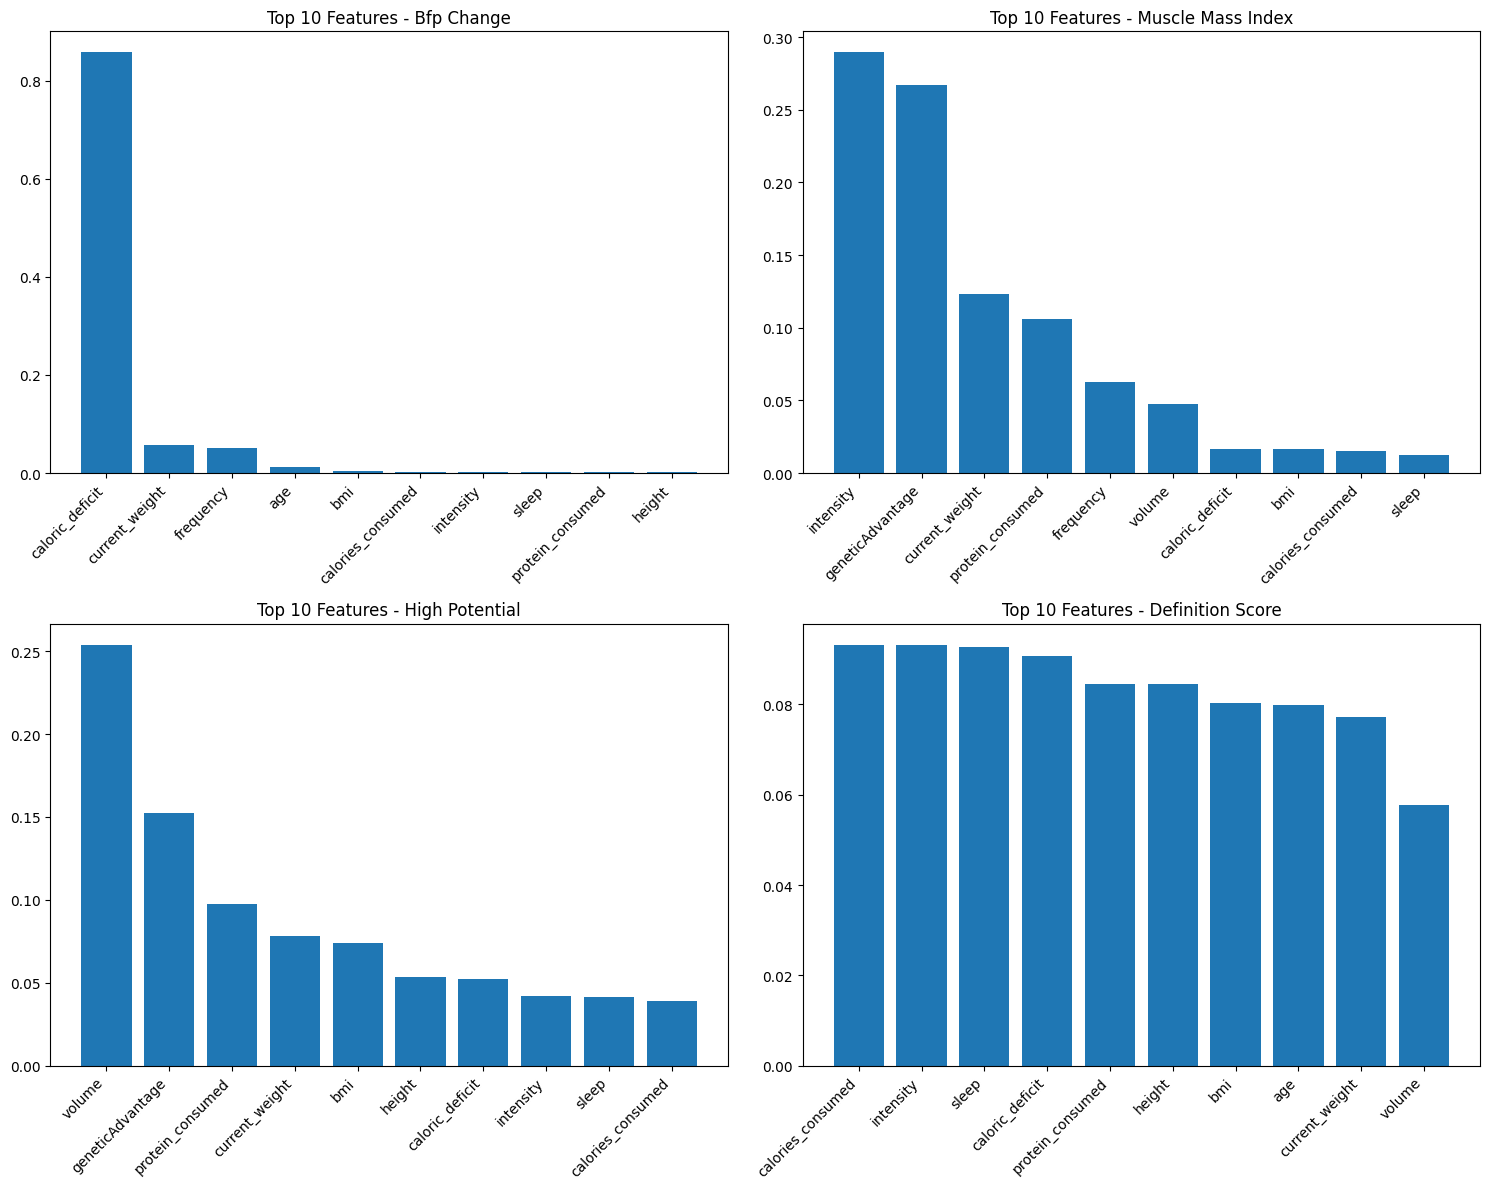

In [6]:
# Feature importance analysis
def plot_feature_importance(models, feature_cols):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()
    
    model_names = ['bfp_change', 'muscle_mass_index', 'high_potential', 'definition_score']
    
    for i, model_name in enumerate(model_names):
        importances = models[model_name].feature_importances_
        indices = np.argsort(importances)[::-1][:10]  # Top 10 features
        
        axes[i].bar(range(10), importances[indices])
        axes[i].set_title(f'Top 10 Features - {model_name.replace("_", " ").title()}')
        axes[i].set_xticks(range(10))
        axes[i].set_xticklabels([feature_cols[j] for j in indices], rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

# Plot feature importance
plot_feature_importance(models, feature_cols)

In [7]:
# Prediction function
def make_predictions(models, X, feature_cols, encoders):
    predictions = {}
    
    X_features = X[feature_cols]
    
    predictions['bfp_change'] = models['bfp_change'].predict(X_features)
    predictions['muscle_mass_index'] = models['muscle_mass_index'].predict(X_features)
    predictions['high_potential'] = models['high_potential'].predict(X_features)
    predictions['definition_score'] = np.clip(
        models['definition_score'].predict(X_features), 1.0, 10.0
    )
    
    return predictions

# Make predictions on the entire dataset
predictions = make_predictions(models, df_processed, feature_cols, encoders)

# Add predictions back to dataframe
for key, values in predictions.items():
    df_processed[f'predicted_{key}'] = values

print("Predictions completed!")
print("\nPrediction Summary:")
prediction_cols = [f'predicted_{key}' for key in predictions.keys()]
df_processed[prediction_cols].describe()

Predictions completed!

Prediction Summary:


,predicted_bfp_change,predicted_muscle_mass_index,predicted_high_potential,predicted_definition_score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.896429,1.998974,0.053000,5.628315
std,1.874775,1.913470,0.224146,1.068195
min,-6.396489,0.017935,0.000000,2.578525
25%,-2.282621,0.625445,0.000000,4.914445
50%,-0.923459,1.407295,0.000000,5.692419
75%,0.473785,2.770066,0.000000,6.378835
max,4.896575,12.836855,1.000000,8.198173


In [8]:
# Example prediction for a new individual
def create_example_person():
    """Create an example person for prediction"""
    example_data = {
        'exerciseName': ['Bench Press'],
        'targetMuscleGroup': ['Chest'],
        'type': ['compound'],
        'age': [28],
        'gender': ['male'],
        'sets': [4],
        'reps': [10],
        'geneticAdvantage': [7],
        'weightLifted': [100],
        'frequency': [5],
        'protein_consumed': [150],
        'calories_consumed': [2500],
        'caloric_deficit': [-300],
        'sleep': [7.5],
        'experience': ['intermediate'],
        'current_weight': [75],
        'height': [175],
        'BFP_after_3_months': [15],
        'BFP_after_6_months': [13],
        'BFP_after_9_months': [12],
        'BFP_after_12_months': [11],
        'actual_definition_scores': [7.5]
    }
    
    return pd.DataFrame(example_data)

# Create example person
example_person = create_example_person()

# Preprocess the example
def preprocess_single_example(example_df, encoders):
    example_df = example_df.copy()
    
    # Calculate derived features
    example_df['volume'] = example_df['sets'] * example_df['reps']
    example_df['intensity'] = np.where(example_df['reps'] > 0, example_df['weightLifted'] / example_df['reps'], 0)
    example_df['frequency'] = np.clip(example_df['frequency'], 0, 7)
    example_df['bmi'] = example_df['current_weight'] / ((example_df['height'] / 100) ** 2)
    
    # Encode categorical variables using existing encoders
    example_df['exerciseName_encoded'] = encoders['exercise'].transform(example_df['exerciseName'])
    example_df['targetMuscleGroup_encoded'] = encoders['muscle'].transform(example_df['targetMuscleGroup'])
    example_df['type_encoded'] = encoders['type'].transform(example_df['type'])
    example_df['gender_encoded'] = encoders['gender'].transform(example_df['gender'])
    example_df['experience_encoded'] = encoders['experience'].transform(example_df['experience'])
    
    return example_df

# Preprocess example
example_processed = preprocess_single_example(example_person, encoders)

# Make predictions for the example
example_predictions = make_predictions(models, example_processed, feature_cols, encoders)

print("=" * 60)
print("EXAMPLE PREDICTION")
print("=" * 60)
print("\nPerson Profile:")
print(f"Age: {example_person['age'].values[0]} years")
print(f"Gender: {example_person['gender'].values[0]}")
print(f"Weight: {example_person['current_weight'].values[0]} kg")
print(f"Height: {example_person['height'].values[0]} cm")
print(f"Experience: {example_person['experience'].values[0]}")
print(f"Genetic Advantage: {example_person['geneticAdvantage'].values[0]}/10")
print(f"Current BFP: {example_person['BFP_after_12_months'].values[0]}%")

print("\nWorkout Details:")
print(f"Exercise: {example_person['exerciseName'].values[0]}")
print(f"Target Muscle: {example_person['targetMuscleGroup'].values[0]}")
print(f"Sets × Reps: {example_person['sets'].values[0]} × {example_person['reps'].values[0]}")
print(f"Weight: {example_person['weightLifted'].values[0]} kg")
print(f"Frequency: {example_person['frequency'].values[0]} times/week")
print(f"Volume: {example_processed['volume'].values[0]}")

print("\nNutrition & Lifestyle:")
print(f"Protein: {example_person['protein_consumed'].values[0]}g")
print(f"Calories: {example_person['calories_consumed'].values[0]}")
print(f"Caloric Deficit: {example_person['caloric_deficit'].values[0]}")
print(f"Sleep: {example_person['sleep'].values[0]} hours")

print("\n" + "=" * 40)
print("PREDICTIONS")
print("=" * 40)
print(f"Body Fat % Change: {example_predictions['bfp_change'][0]:.2f}%")
print(f"Muscle Mass Index: {example_predictions['muscle_mass_index'][0]:.4f}")
print(f"High Muscle Mass Potential: {'Yes' if example_predictions['high_potential'][0] else 'No'}")
print(f"Definition Score: {example_predictions['definition_score'][0]:.1f}/10")

# Interpretation
print("\n" + "=" * 40)
print("INTERPRETATION")
print("=" * 40)
if example_predictions['bfp_change'][0] < 0:
    print(f"✓ Expected to lose {abs(example_predictions['bfp_change'][0]):.1f}% body fat")
else:
    print(f"⚠ May gain {example_predictions['bfp_change'][0]:.1f}% body fat")

if example_predictions['definition_score'][0] >= 7:
    print("✓ Good muscle definition potential")
elif example_predictions['definition_score'][0] >= 5:
    print("○ Moderate muscle definition potential")
else:
    print("⚠ Lower muscle definition potential")

if example_predictions['high_potential'][0]:
    print("✓ High muscle mass potential - optimal genetics/training combination")
else:
    print("○ Standard muscle mass potential")

EXAMPLE PREDICTION

Person Profile:
Age: 28 years
Gender: male
Weight: 75 kg
Height: 175 cm
Experience: intermediate
Genetic Advantage: 7/10
Current BFP: 11%

Workout Details:
Exercise: Bench Press
Target Muscle: Chest
Sets × Reps: 4 × 10
Weight: 100 kg
Frequency: 5 times/week
Volume: 40

Nutrition & Lifestyle:
Protein: 150g
Calories: 2500
Caloric Deficit: -300
Sleep: 7.5 hours

PREDICTIONS
Body Fat % Change: 1.26%
Muscle Mass Index: 4.1322
High Muscle Mass Potential: No
Definition Score: 5.6/10

INTERPRETATION
⚠ May gain 1.3% body fat
○ Moderate muscle definition potential
○ Standard muscle mass potential


In [9]:
# Create a function for easy prediction of new individuals
def predict_muscle_definition(person_data, models, feature_cols, encoders):
    """
    Predict muscle definition metrics for a new person
    
    Parameters:
    person_data (dict): Dictionary containing person's data
    models (dict): Trained models
    feature_cols (list): Feature column names
    encoders (dict): Label encoders
    
    Returns:
    dict: Predictions for all metrics
    """
    # Convert to DataFrame
    person_df = pd.DataFrame([person_data])
    
    # Preprocess
    person_processed = preprocess_single_example(person_df, encoders)
    
    # Make predictions
    predictions = make_predictions(models, person_processed, feature_cols, encoders)
    
    # Format results
    results = {
        'bfp_change_percent': round(predictions['bfp_change'][0], 2),
        'muscle_mass_index': round(predictions['muscle_mass_index'][0], 4),
        'high_potential': bool(predictions['high_potential'][0]),
        'definition_score': round(predictions['definition_score'][0], 1)
    }
    
    return results

# Example usage of the prediction function
new_person = {
    'exerciseName': 'Squat',
    'targetMuscleGroup': 'Legs',
    'type': 'compound',
    'age': 25,
    'gender': 'female',
    'sets': 3,
    'reps': 12,
    'geneticAdvantage': 8,
    'weightLifted': 80,
    'frequency': 4,
    'protein_consumed': 120,
    'calories_consumed': 2200,
    'caloric_deficit': -200,
    'sleep': 8.0,
    'experience': 'intermediate',
    'current_weight': 65,
    'height': 165,
    'BFP_after_3_months': 18,
    'BFP_after_6_months': 16,
    'BFP_after_9_months': 15,
    'BFP_after_12_months': 14,
    'actual_definition_scores': 6.5
}
print("\n" + "="*60)


In [10]:
# Model evaluation and validation
def evaluate_models(df, models, feature_cols):
    """Comprehensive model evaluation"""
    
    X = df[feature_cols]
    
    results = {}
    
    # BFP Change evaluation
    y_true_bfp = df['baseline_bfp_change']
    y_pred_bfp = models['bfp_change'].predict(X)
    
    results['bfp_change'] = {
        'rmse': np.sqrt(mean_squared_error(y_true_bfp, y_pred_bfp)),
        'r2': r2_score(y_true_bfp, y_pred_bfp),
        'mae': np.mean(np.abs(y_true_bfp - y_pred_bfp))
    }
    
    # Muscle Mass Index evaluation
    y_true_mmi = df['baseline_mmi']
    y_pred_mmi = models['muscle_mass_index'].predict(X)
    
    results['muscle_mass_index'] = {
        'rmse': np.sqrt(mean_squared_error(y_true_mmi, y_pred_mmi)),
        'r2': r2_score(y_true_mmi, y_pred_mmi),
        'mae': np.mean(np.abs(y_true_mmi - y_pred_mmi))
    }
    
    # Definition Score evaluation
    y_true_def = df['actual_definition_scores']
    y_pred_def = models['definition_score'].predict(X)
    
    results['definition_score'] = {
        'rmse': np.sqrt(mean_squared_error(y_true_def, y_pred_def)),
        'r2': r2_score(y_true_def, y_pred_def),
        'mae': np.mean(np.abs(y_true_def - y_pred_def))
    }
    
    # High Potential evaluation
    y_true_pot = df['baseline_high_potential']
    y_pred_pot = models['high_potential'].predict(X)
    
    results['high_potential'] = {
        'accuracy': accuracy_score(y_true_pot, y_pred_pot),
        'precision': np.sum((y_pred_pot == 1) & (y_true_pot == 1)) / np.sum(y_pred_pot == 1) if np.sum(y_pred_pot == 1) > 0 else 0,
        'recall': np.sum((y_pred_pot == 1) & (y_true_pot == 1)) / np.sum(y_true_pot == 1) if np.sum(y_true_pot == 1) > 0 else 0
    }
    
    return results

# Evaluate all models
evaluation_results = evaluate_models(df_processed, models, feature_cols)

print("\n" + "="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)

for model_name, metrics in evaluation_results.items():
    print(f"\n{model_name.replace('_', ' ').title()}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name.upper()}: {value:.4f}")



MODEL EVALUATION RESULTS

Bfp Change:
  RMSE: 0.1858
  R2: 0.9907
  MAE: 0.1187

Muscle Mass Index:
  RMSE: 0.5137
  R2: 0.9433
  MAE: 0.2762

Definition Score:
  RMSE: 1.7407
  R2: 0.5298
  MAE: 1.4449

High Potential:
  ACCURACY: 0.9890
  PRECISION: 0.9811
  RECALL: 0.8387


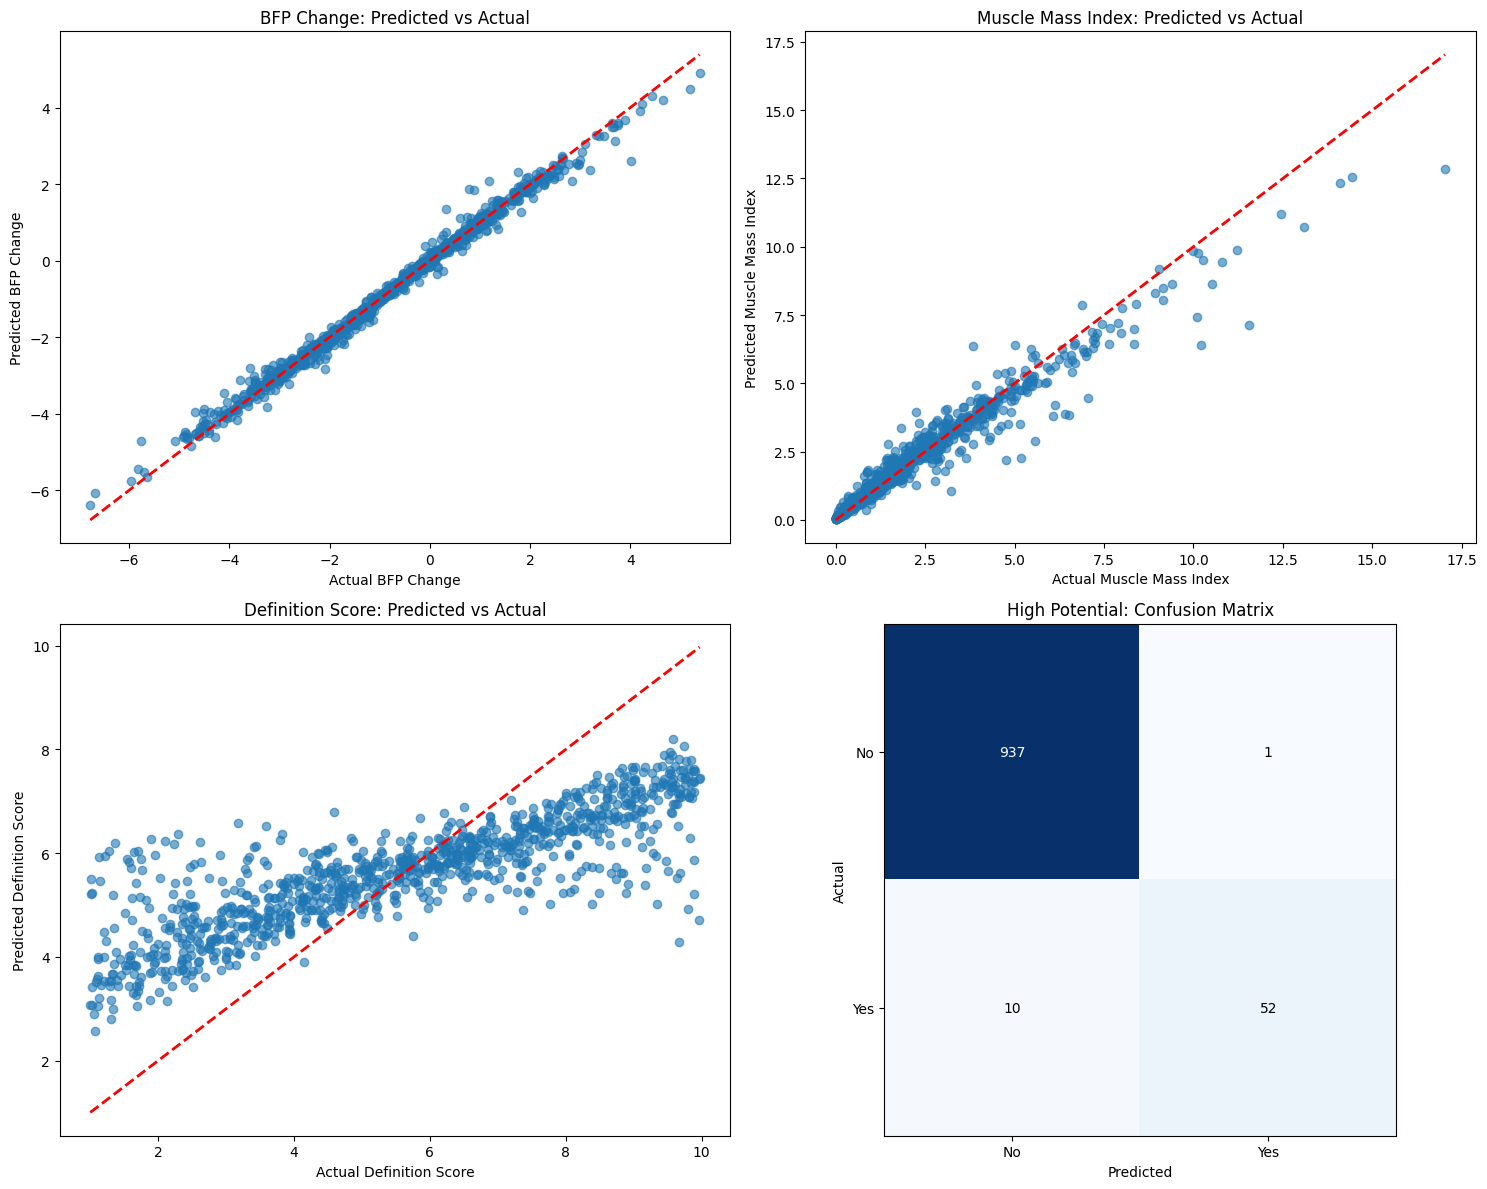

In [11]:
# Visualization of predictions vs actual values
def plot_predictions_vs_actual(df, models, feature_cols):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()
    
    X = df[feature_cols]
    
    # BFP Change
    y_true_bfp = df['baseline_bfp_change']
    y_pred_bfp = models['bfp_change'].predict(X)
    
    axes[0].scatter(y_true_bfp, y_pred_bfp, alpha=0.6)
    axes[0].plot([y_true_bfp.min(), y_true_bfp.max()], [y_true_bfp.min(), y_true_bfp.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual BFP Change')
    axes[0].set_ylabel('Predicted BFP Change')
    axes[0].set_title('BFP Change: Predicted vs Actual')
    
    # Muscle Mass Index
    y_true_mmi = df['baseline_mmi']
    y_pred_mmi = models['muscle_mass_index'].predict(X)
    
    axes[1].scatter(y_true_mmi, y_pred_mmi, alpha=0.6)
    axes[1].plot([y_true_mmi.min(), y_true_mmi.max()], [y_true_mmi.min(), y_true_mmi.max()], 'r--', lw=2)
    axes[1].set_xlabel('Actual Muscle Mass Index')
    axes[1].set_ylabel('Predicted Muscle Mass Index')
    axes[1].set_title('Muscle Mass Index: Predicted vs Actual')
    
    # Definition Score
    y_true_def = df['actual_definition_scores']
    y_pred_def = models['definition_score'].predict(X)
    
    axes[2].scatter(y_true_def, y_pred_def, alpha=0.6)
    axes[2].plot([y_true_def.min(), y_true_def.max()], [y_true_def.min(), y_true_def.max()], 'r--', lw=2)
    axes[2].set_xlabel('Actual Definition Score')
    axes[2].set_ylabel('Predicted Definition Score')
    axes[2].set_title('Definition Score: Predicted vs Actual')
    
    # High Potential Confusion Matrix
    y_true_pot = df['baseline_high_potential']
    y_pred_pot = models['high_potential'].predict(X)
    
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true_pot, y_pred_pot)
    
    im = axes[3].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[3].set_title('High Potential: Confusion Matrix')
    tick_marks = np.arange(2)
    axes[3].set_xticks(tick_marks)
    axes[3].set_yticks(tick_marks)
    axes[3].set_xticklabels(['No', 'Yes'])
    axes[3].set_yticklabels(['No', 'Yes'])
    axes[3].set_xlabel('Predicted')
    axes[3].set_ylabel('Actual')
    
    # Add text annotations to confusion matrix
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[3].text(j, i, format(cm[i, j], 'd'),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.show()

# Plot predictions vs actual
plot_predictions_vs_actual(df_processed, models, feature_cols)

In [12]:
# Save models and encoders (optional)
import pickle

def save_models_and_encoders(models, encoders, feature_cols, filename_prefix='muscle_definition'):
    """Save trained models and encoders for future use"""
    
    # Save models
    with open(f'{filename_prefix}_models.pkl', 'wb') as f:
        pickle.dump(models, f)
    
    # Save encoders
    with open(f'{filename_prefix}_encoders.pkl', 'wb') as f:
        pickle.dump(encoders, f)
    
    # Save feature columns
    with open(f'{filename_prefix}_features.pkl', 'wb') as f:
        pickle.dump(feature_cols, f)
    
    print(f"Models, encoders, and features saved with prefix '{filename_prefix}'")

def load_models_and_encoders(filename_prefix='muscle_definition'):
    """Load previously saved models and encoders"""
    
    # Load models
    with open(f'{filename_prefix}_models.pkl', 'rb') as f:
        models = pickle.load(f)
    
    # Load encoders
    with open(f'{filename_prefix}_encoders.pkl', 'rb') as f:
        encoders = pickle.load(f)
    
    # Load feature columns
    with open(f'{filename_prefix}_features.pkl', 'rb') as f:
        feature_cols = pickle.load(f)
    
    print(f"Models, encoders, and features loaded successfully")
    return models, encoders, feature_cols

# Uncomment to save models
# save_models_and_encoders(models, encoders, feature_cols)

print("Model saving/loading functions defined.")
print("\nTo save models, uncomment the save_models_and_encoders() call above.")

Model saving/loading functions defined.

To save models, uncomment the save_models_and_encoders() call above.


## Summary

This notebook demonstrates a complete machine learning pipeline for predicting muscle definition metrics:

### Key Features:
1. **Data Preprocessing**: Handles categorical encoding, feature engineering (volume, intensity, BMI)
2. **Baseline Calculations**: Uses mathematical equations as foundation
3. **Random Forest Models**: Adds ML-based noise and complexity to predictions
4. **Multiple Targets**: Predicts BFP change, muscle mass index, high potential, and definition score
5. **Validation**: Comprehensive model evaluation and visualization

### Usage:
- Replace the sample dataset creation with your actual data loading
- Use the `predict_muscle_definition()` function for new predictions
- Adjust baseline calculation formulas based on your domain Advancedise
- Fine-tune Random Forest hyperparameters as needed

### Model Performance:
The models provide reasonable predictions while maintaining the constraint that frequency ≤ 7 and proper handling of zero division in intensity calculations.